In [1]:
import torch.utils.data as data
import numpy as np
import os
import sys
from PIL import Image
import torch
import random
import math
from tqdm import tqdm
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import subprocess
from collections import defaultdict

from torch.autograd import Variable
from torchinfo import summary

import multiprocessing as mp

sys.path.append("../src/")
print(torchvision.__version__)
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.current_device())
data_root_dir = "D:/eat_detection/results/"
import matplotlib.pyplot as plt
import os
import numpy as np
import matplotlib

#data_root_dir = "/scratch1/zeyut/eat_detection/"

/home/zeyut/.conda/envs/torch-1.13/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.14.1+cu117
1.13.1+cu117
False


RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

### Test middle features of the 1st stage model

In [2]:
softmax_layer = nn.Softmax(dim=0)
sigmoid_layer = nn.Sigmoid()

In [6]:
a = [5,2,1]
input = torch.FloatTensor(a)
softmax_output = softmax_layer(input)
sigmoid_output = sigmoid_layer(input)

In [7]:
print(f"input: {input.tolist()}")
print(f"soft max output: {softmax_output.tolist()}")
print(f"sigmoid output: {sigmoid_output.tolist()}")

input: [5.0, 2.0, 1.0]
soft max output: [0.9362395405769348, 0.04661262035369873, 0.01714782603085041]
sigmoid output: [0.9933071732521057, 0.8807970285415649, 0.7310585975646973]


In [9]:
from models import RES_LSTM

model_loc = "D:/eat_detection/results/1/model_RES_LSTM_30_16_8_v4/"

print("load the best model for testing")
sys.stdout.flush()
model = RES_LSTM(seq_len=16).cuda()
model = torch.nn.DataParallel(model).cuda()
try:
    checkpoint = torch.load(os.path.join(model_loc, f"checkpoint_best.tar"))
except:
    print("no 'checkpoint_best.tar' is found")
    exit(0)
model.load_state_dict(checkpoint['model_state_dict'])

load the best model for testing


<All keys matched successfully>

In [10]:
summary(model, input_size=(32,16, 3, 128, 128))  

D:\Anaconda3\envs\torch-1.9\lib\site-packages\torch\nn\functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  ..\c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)


Layer (type:depth-idx)                                  Output Shape              Param #
DataParallel                                            --                        --
├─RES_LSTM: 1-1                                         [32, 16, 3]               --
│    └─Spatial_Encoder: 2-1                             [32, 16, 512, 1, 1]       --
│    │    └─Sequential: 3-1                             [512, 512, 1, 1]          21,284,672
│    └─Flatten: 2-2                                     [32, 16, 512]             --
│    └─BatchNorm1d: 2-3                                 [32, 16, 512]             32
│    └─LSTM: 2-4                                        [32, 16, 128]             460,800
│    └─Dropout: 2-5                                     [32, 16, 128]             --
│    └─Sequential: 2-6                                  [32, 16, 3]               --
│    │    └─Linear: 3-2                                 [32, 16, 3]               387
│    │    └─ReLU: 3-3                         

In [11]:
data_path = "D:/eat_detection/VideoData_independent/test_set/p016_c1/"
f = open(os.path.join(data_path,"gt_frame_3labels.txt"),"r")
gt_frame = [str.split(line, "\t") for line in f.readlines()]

preprocess = transforms.Compose([
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])
    
sample = []
count = 0
for frame_info in gt_frame[0:16]:
    frame_loc = os.path.join(data_path,frame_info[0])
    sample.append(Image.open(frame_loc).convert('RGB'))

sample = torch.stack([transforms.functional.to_tensor(frame) for frame in sample])
sample = preprocess(sample)
sample = torch.unsqueeze(sample, 0)

In [12]:
sample.size()

torch.Size([1, 16, 3, 224, 224])

In [13]:
output,output_2 = model(sample)

In [14]:
output_2

tensor([[[ 0.0000,  2.2702,  2.7893],
         [ 0.0000,  4.0673,  4.0746],
         [ 0.0000,  3.7475,  5.6147],
         [ 0.0000,  2.3581,  8.9268],
         [ 0.0000,  1.0783,  9.0015],
         [ 0.0000,  0.3275,  8.9307],
         [ 0.0000,  0.0000, 11.6178],
         [ 0.0000,  0.0000,  9.7797],
         [ 0.0000,  0.0000, 10.9554],
         [ 0.5395,  0.0000, 10.3798],
         [ 0.0000,  0.1170, 11.9309],
         [ 7.3772,  0.0000,  4.2686],
         [ 7.2203,  0.0000,  0.0000],
         [ 8.2468,  0.0000,  0.4476],
         [12.2051,  0.0000,  0.2572],
         [10.5540,  0.0000,  0.2996]]], device='cuda:0',
       grad_fn=<ReluBackward0>)

In [17]:
softmax_layer = nn.Softmax(dim=1)
sigmoid_layer = nn.Sigmoid()

In [43]:
input = output_2.squeeze()
softmax_output = softmax_layer(input).squeeze().tolist()
sigmoid_output = sigmoid_layer(input).squeeze().tolist()
input = input.tolist()
for idx in range(16):
    message = f"input: {input[idx][0]:>0.4f} {input[idx][1]:>0.4f} {input[idx][2]:>0.4f}\t\
            softmax: {softmax_output[idx][0]:>0.4f} {softmax_output[idx][1]:>0.4f} {softmax_output[idx][2]:>0.4f}\t\
            sigmoid: {sigmoid_output[idx][0]:>0.4f} {sigmoid_output[idx][1]:>0.4f} {sigmoid_output[idx][2]:>0.4f}"
    print(message)

input: 0.0000 2.2702 2.7893	            softmax: 0.0371 0.3592 0.6037	            sigmoid: 0.5000 0.9064 0.9421
input: 0.0000 4.0673 4.0746	            softmax: 0.0085 0.4940 0.4976	            sigmoid: 0.5000 0.9832 0.9833
input: 0.0000 3.7475 5.6147	            softmax: 0.0031 0.1334 0.8634	            sigmoid: 0.5000 0.9770 0.9964
input: 0.0000 2.3581 8.9268	            softmax: 0.0001 0.0014 0.9985	            sigmoid: 0.5000 0.9136 0.9999
input: 0.0000 1.0783 9.0015	            softmax: 0.0001 0.0004 0.9995	            sigmoid: 0.5000 0.7462 0.9999
input: 0.0000 0.3275 8.9307	            softmax: 0.0001 0.0002 0.9997	            sigmoid: 0.5000 0.5812 0.9999
input: 0.0000 0.0000 11.6178	            softmax: 0.0000 0.0000 1.0000	            sigmoid: 0.5000 0.5000 1.0000
input: 0.0000 0.0000 9.7797	            softmax: 0.0001 0.0001 0.9999	            sigmoid: 0.5000 0.5000 0.9999
input: 0.0000 0.0000 10.9554	            softmax: 0.0000 0.0000 1.0000	            sigmoid: 0.5000 0.50

In [41]:
input[idx]

[0.0, 2.270198106765747, 2.7892556190490723]

### Test 2nd stage dataset class and get global Mean and Std.

In [56]:
class probabilityDataset(data.Dataset):
    def __init__(self,
                  data_loc,
                  gt_loc,
                  mode="train",
                  label_type="all",
                  run_times=10,
                  raw_seq_len=16,
                  raw_stride=1,
                  downsample_rate=4,
                  raw_sample_len=20000):
        'Initialization'
        self.finish_initialize = False
        sample_list = []
        label_list = []
        read_samples_args = []
        self.label_type = label_type
        self.raw_seq_len = raw_seq_len
        self.raw_sample_len = raw_sample_len
        self.downsample_rate = downsample_rate
        self.raw_stride = raw_stride
        if label_type in ["bite","drink"]:
            self.feature_num = 2
        elif label_type == "all":
            self.feature_num = 3
        self.mean_list = []
        self.std_list = []
        '''
        # use features from run_times runs for training
        for model_idx in range(1,run_times+1):
            feature_loc = os.path.join(data_loc,f"{model_idx}/result_RES_LSTM_30_16_8_v4_{mode}/frame_features/")
            read_samples_args.append([feature_loc,gt_loc,model_idx])
        pool = mp.Pool(10)
        ret = pool.map(self.read_raw_samples,read_samples_args)

        for data in ret:
            sample_list.append(data[0])
            label_list.append(data[1])
            self.mean_list.append(data[2])
            self.std_list.append(data[3])
        self.sample_list = np.concatenate(sample_list)
        self.label_list = np.concatenate(label_list)
        
        pool.close()  
        pool.join() 
        np.savetxt(os.path.join(data_loc,f"train_mean_{label_type}.txt"),np.array(self.mean_list))
        np.savetxt(os.path.join(data_loc,f"train_std_{label_type}.txt"),np.array(self.std_list))
        '''
        self.finish_initialize = True
        
    def __len__(self):
        return len(self.label_list)
    
    def __getitem__(self, idx):
        return self.sample_list[idx],self.label_list[idx]
    
    def read_raw_samples(self, args):
        sample_loc,gt_loc,model_idx = args[0],args[1],args[2]
        video_list = ["_".join(f.split(".")[0].split("_")[1:3]) for f in os.listdir(sample_loc)]
        #video_list = ["p072_c1"]
        samples = []
        labels = []
        count = 0
        #len_list = []
        for video_idx in video_list:
            cur_samples,cur_labels = self.read_features(sample_loc, gt_loc, video_idx)
            samples.append(cur_samples)
            labels.append(cur_labels)
            #len_list.append(np.sum(cur_labels[0]!=-1))
            #count += 1
            #if count > 1:
             #   break
        
        samples = np.concatenate(samples) 
        labels = np.concatenate(labels)
        mean = []
        std = []
        # standarization per model, and per feature
        for feature_idx in range(self.feature_num):
            cur_mean = samples[labels!=-1,feature_idx].mean(axis=0)
            cur_std = samples[labels!=-1,feature_idx].std(axis=0)
            samples[labels!=-1,feature_idx] = (samples[labels!=-1,feature_idx]-cur_mean)/cur_std
            mean.append(cur_mean)
            std.append(cur_std)
            
        # downsample
        samples = samples[:,::self.downsample_rate,:]
        labels = labels[:,::self.downsample_rate]
        mean = np.array(mean)
        std = np.array(std)
        return samples, labels, mean, std
        #return samples, labels, mean, std, np.array(len_list),video_list
  
    def read_features(self, feature_loc, gt_loc, video_idx):
        f_gt = open(os.path.join(gt_loc,video_idx,"gt_frame_3labels.txt"),"r")
        gt_content = f_gt.readlines()
        f_gt.close()         
        
        f_feature = open(os.path.join(feature_loc,f"features_{video_idx}.txt"),"r")
        if self.label_type == "all":
            # default sample value is 0, and default label is -1( will be ingored when computing loss)
            samples = np.zeros((self.raw_seq_len,self.raw_sample_len,3)) 
            labels = np.ones((self.raw_seq_len,self.raw_sample_len)) * (-1)            
            for row_idx, line in enumerate(f_feature.readlines()):
                seq_features = line.split("\n")[0].split("\t")[1:]
                for col_idx in range(0,len(seq_features),3):
                    position_idx = col_idx // 3  # the frame index in the current sequence
                    frame_idx = row_idx * self.raw_stride + position_idx  # the frame index in the current frame list
                    samples[position_idx,frame_idx,0:3] = seq_features[col_idx:col_idx+3]
            frame_gt = np.array([LABEL_TABLE[line.split("\n")[0].split("\t")[1]] for line in gt_content])
            
        if self.label_type in ["bite","drink"]:
            samples = np.zeros((self.raw_seq_len,self.raw_sample_len,2)) 
            labels = np.ones((self.raw_seq_len,self.raw_sample_len)) * (-1)       
            target_position = 0 if self.label_type == "bite" else 1
            for row_idx, line in enumerate(f_feature.readlines()):
                seq_features = line.split("\n")[0].split("\t")[1:]
                for col_idx in range(0,len(seq_features),3):
                    position_idx = col_idx // 3  # the frame index in the current sequence
                    frame_idx = row_idx * self.raw_stride + position_idx  # the frame index in the current video frame list
                    samples[position_idx,frame_idx,0] = seq_features[col_idx+target_position]
                    samples[position_idx,frame_idx,1] = seq_features[col_idx+2]
                    
            frame_gt = np.array([LABEL_TABLE[line.split("\n")[0].split("\t")[1]] for line in gt_content])
            frame_gt = (frame_gt==LABEL_TABLE[self.label_type]).astype("int")
        f_feature.close()

        for idx in range(0,self.raw_seq_len):
            labels[idx,idx:idx+len(frame_gt)-self.raw_seq_len+1] = frame_gt[idx:idx+len(frame_gt)-self.raw_seq_len+1]
            
        return samples.astype("float"),labels.astype("int")

In [57]:
sys.path.append("../src")

from constants import LABEL_TABLE
raw_sample_len = 20000
downsample_rate = 4
raw_seq_len = 16
LABEL_TABLE = {"bite": 0, "drink": 1, "non_intake": 2}
#MEAN = [1.80444053, 0.80193992, 11.10639638]
#STD = [4.21282851, 3.02531022, 5.59236825]
train_set = probabilityDataset(
                    data_loc = data_root_dir + "results_10runs/",
                    gt_loc = data_root_dir + "all_labels/",
                    mode = "train",
                    label_type="all",
                    run_times = 10,
                    raw_seq_len = raw_seq_len,
                    downsample_rate = downsample_rate,
                    raw_sample_len = raw_sample_len
                    )

#### Max length of the training videos

In [60]:
samples,labels,_,_ = train_set.read_raw_samples([data_root_dir + "results_10runs/1/result_RES_LSTM_30_16_8_v4_train/frame_features/",
                           "/scratch1/zeyut/eat_detection/all_labels/",
                           1])

In [87]:
len(len_list)

333

In [86]:
max_len = max(len_list)
print(max_len)
max_idx = list(len_list).index(max_len)
print(max_idx)
print(video_list[max_idx])

19794
210
p232_c1


In [212]:
print(samples.shape)
print(labels.shape)

(32, 5000, 2)
(32, 5000)


In [213]:
data_loc = data_root_dir + "results_10runs/"
label_type = "bite"
mean_list = np.loadtxt(os.path.join(data_loc,f"train_mean_{label_type}.txt"))

In [214]:
mean = mean_list[0]
mean

array([2.328736  , 7.41771165])

In [215]:
test = samples-mean

In [216]:
samples[0]

array([[-0.70503424, -0.36602196],
       [-0.70503424, -0.34310356],
       [-0.70503424, -0.34310356],
       ...,
       [ 0.        ,  0.        ],
       [ 0.        ,  0.        ],
       [ 0.        ,  0.        ]])

In [217]:
test[0]

array([[-3.03377024, -7.78373361],
       [-3.03377024, -7.76081521],
       [-3.03377024, -7.76081521],
       ...,
       [-2.328736  , -7.41771165],
       [-2.328736  , -7.41771165],
       [-2.328736  , -7.41771165]])

### Mean and std of 1st-model's features in trainset

In [35]:
aver = train_set.sample_list[train_set.label_list!=-1].mean(axis=0)
std = train_set.sample_list[train_set.label_list!=-1].std(axis=0)
print(f"train set mean: {aver}")
print(f"train set std: {std}")

train set mean: [0.00190904]
train set std: [1.00029144]


In [ ]:
z = train_set.sample_list
z[train_set.label_list!=-1] = (train_set.sample_list[train_set.label_list!=-1] - aver)/std

In [ ]:
z.shape

In [ ]:
train_set.sample_list[0][4990:5000]

In [ ]:
z[0][4990:5000]

### Visualize 2-stage model details

In [1]:
import torch.utils.data as data
import numpy as np
import os
import sys
from PIL import Image
import torch
import random
import math
from tqdm import tqdm
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import subprocess
from collections import defaultdict

from torch.autograd import Variable
from torchinfo import summary

import multiprocessing as mp

sys.path.append("../src/")

data_root_dir = "/scratch1/zeyut/eat_detection/"

from train_2nd_model import single_LSTM,double_LSTM,read_features,test_2nd_stage

In [2]:
LABEL_NUM=3
model = single_LSTM(seq_len=6250).cuda()
summary(model, input_size=(32,6250,3))

Layer (type:depth-idx)                   Output Shape              Param #
├─LSTM: 1-1                              [32, 6250, 64]            50,944
├─BatchNorm1d: 1-2                       [32, 6250, 64]            --
├─Dropout: 1-3                           [32, 6250, 64]            --
├─Sequential: 1-4                        [32, 6250, 3]             --
|    └─Linear: 2-1                       [32, 6250, 3]             195
|    └─ReLU: 2-2                         [32, 6250, 3]             --
├─Softmax: 1-5                           [32, 6250, 3]             --
Total params: 51,139
Trainable params: 51,139
Non-trainable params: 0
Total mult-adds (G): 10.02
Input size (MB): 2.40
Forward/backward pass size (MB): 107.20
Params size (MB): 0.20
Estimated Total Size (MB): 109.80

In [3]:
data_loc = "/scratch1/zeyut/eat_detection/results/"    
model_idx = 1
test_loc = "tmp"
fps =5 
video_idx,samples,frame_names,frame_gt = test_2nd_stage(model = model,
                        data_loc = os.path.join(data_loc,f"{model_idx}/result_test/frame_features/"), 
                        gt_loc = f"/scratch1/zeyut/eat_detection/VideoData_independent_{fps}hz/test_set/",
                        test_save_loc = os.path.join(test_loc,f"{model_idx}"),
                        mean = [1,1,1],
                        std = [1,1,1],
                        label_type = "all",
                        downsample_rate = 2, 
                        raw_sample_len = 12500,
                        raw_seq_len = 13,
                        test_stride = 1)     

In [5]:
video_idx

'p217_c3'

### Test the evaluation function for the 2-stage model output

In [2]:
import matplotlib.pyplot as plt
from train_2nd_model import single_LSTM,read_features
from constants import LABEL_NUM,MEAN,STD

In [3]:
downsample_rate = 4
raw_sample_len = 20000
sample_len = int(raw_sample_len/downsample_rate)
data_loc = data_root_dir + "results_10runs/1/result_RES_LSTM_30_16_8_v4_train/frame_features/"

gt_loc = data_root_dir + "all_labels/"
model_loc = data_root_dir + "model_single_lstm_50_16_8_v4_2stage_all/"
test_save_loc = "../tmp"

mean_list = np.loadtxt(data_root_dir + "results_10runs/train_mean_all.txt")
std_list = np.loadtxt(data_root_dir + "results_10runs/train_std_all.txt")

try:
    os.mkdir(test_save_loc)
except:
    pass
try:
    os.mkdir(os.path.join(test_save_loc,"frame_probs"))
except:
    pass
try:
    os.mkdir(os.path.join(test_save_loc,"frame_preds"))
except:
    pass  

In [4]:
model = single_LSTM(seq_len=sample_len,label_num=LABEL_NUM).cuda()
model = torch.nn.DataParallel(model).cuda()
checkpoint = torch.load(os.path.join(model_loc, f"checkpoint_best.tar"))
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [18]:
def test_2nd_stage(model, 
                    data_loc, 
                    gt_loc, 
                    test_save_loc,
                    mean,
                    std,
                    label_type="all",
                    downsample_rate=4, 
                    test_stride=1):        
    test_video_list = ["_".join(f.split(".")[0].split("_")[1:3]) for f in os.listdir(data_loc)]
    all_samples = []
    all_labels = []
    for video_idx in test_video_list[15:]:
        print(video_idx)
        raw_samples,raw_labels,raw_frame_gt,raw_frame_names = read_features(data_loc,gt_loc,video_idx,label_type)
        # Besides of downsampling samples, 
        # also resample in the raw sequence with test_stride*downsample_rate fps. 
        # That is equivalent with applying test_stride stride on the downsampled raw data.  
        samples = raw_samples[::test_stride*downsample_rate,::downsample_rate,:]
        labels = raw_labels[::test_stride*downsample_rate,::downsample_rate]
        frame_gt = raw_frame_gt[::test_stride*downsample_rate]
        print(raw_frame_names)
        frame_names = raw_frame_names[::test_stride*downsample_rate]
        # Standardization
        samples[labels!=-1] = (samples[labels!=-1]-mean)/std
        print(mean,std)
        all_samples.append(samples)
        all_labels.append(labels)
        
        input = torch.from_numpy(samples).type(torch.cuda.FloatTensor)
        input = Variable(input).cuda()
        output = model(input)
        probs = output.detach().cpu().numpy()
        preds = probs.argmax(-1)
        #correct = (preds[0] == labels[0]).sum().item()
        #print(correct)        
        
        if label_type in ["bite","drink"]:
            heat_map = np.zeros((len(samples[0]),2))
        else:
            heat_map = np.zeros((len(samples[0]),LABEL_NUM))

        for sample_idx in range(len(preds)):
            cur_label = labels[sample_idx]
            cur_prob = probs[sample_idx][cur_label!=-1]
            cur_pred = preds[sample_idx][cur_label!=-1]
            cur_names = frame_names[cur_label[:len(frame_names)]!=-1]
            for frame_idx in range(len(cur_pred)):
                heat_map[sample_idx*test_stride + frame_idx][cur_pred[frame_idx]] += 1
            f_probs = open(os.path.join(test_save_loc,"frame_probs",f"probs_{video_idx}_{sample_idx}.txt"),'w')
            for name, prob_group in zip(cur_names,cur_prob):
                # frame's indexes start from 1.
                frame_idx = int(name[6:-4])
                f_probs.write("{}".format(frame_idx))
                for prob_value in prob_group:
                    f_probs.write("\t{0:.6f}".format(prob_value))
                f_probs.write("\n")
            f_probs.close()   
            f_preds = open(os.path.join(test_save_loc,"frame_preds",f"sub_preds_{video_idx}_{sample_idx}.txt"),'w')
            f_preds.write("\n".join(["{}\t{}\t{}".format(i,int(j),int(k)) for i,j,k in \
                                        (zip(frame_names[cur_label[:len(frame_names)]!=-1],cur_label[cur_label!=-1],cur_pred))]))
            f_preds.close()
        final_preds = np.argmax(heat_map, axis=-1)
        
        '''
        # upsample final predictions to original 8hz
        upsampled_preds = np.zeros(len(raw_frame_gt))
        for pred_idx in range(len(upsampled_preds)):
            upsampled_preds[pred_idx] = final_preds[round(pred_idx/downsample_rate)]
        '''
        '''
        f_results = open(os.path.join(test_save_loc,"frame_preds",f"preds_{video_idx}.txt"),'w')
        f_results.write("\n".join(["{}\t{}\t{}".format(i,int(j),int(k)) for i,j,k in (zip(frame_name,frame_gt,final_preds))]))
        f_results.close() 
        '''
    return all_samples,all_labels    


In [19]:
a,b = test_2nd_stage(model=model, 
                        data_loc=data_loc, 
                        gt_loc=gt_loc, 
                        test_save_loc=test_save_loc,
                        mean=mean_list[0],
                        std=std_list[0],
                        label_type="all",
                        downsample_rate=4, 
                        test_stride=1) 


p182_c1
['frame_000030.ppm' 'frame_000031.ppm' 'frame_000032.ppm' ...
 'frame_002645.ppm' 'frame_002646.ppm' 'frame_002647.ppm']
[1.90514563 0.85021104 8.40838936] [3.10173766 2.73265356 4.21762627]
p109_c2
['frame_000001.ppm' 'frame_000002.ppm' 'frame_000003.ppm' ...
 'frame_006970.ppm' 'frame_006971.ppm' 'frame_006972.ppm']
[1.90514563 0.85021104 8.40838936] [3.10173766 2.73265356 4.21762627]
p036_c2
['frame_000125.ppm' 'frame_000126.ppm' 'frame_000127.ppm' ...
 'frame_001826.ppm' 'frame_001827.ppm' 'frame_001828.ppm']
[1.90514563 0.85021104 8.40838936] [3.10173766 2.73265356 4.21762627]
p089_c1
['frame_000024.ppm' 'frame_000025.ppm' 'frame_000026.ppm' ...
 'frame_010804.ppm' 'frame_010805.ppm' 'frame_010806.ppm']
[1.90514563 0.85021104 8.40838936] [3.10173766 2.73265356 4.21762627]
p079_c2
['frame_000205.ppm' 'frame_000206.ppm' 'frame_000207.ppm' ...
 'frame_004911.ppm' 'frame_004912.ppm' 'frame_004913.ppm']
[1.90514563 0.85021104 8.40838936] [3.10173766 2.73265356 4.21762627]
p068_

KeyboardInterrupt: 

In [49]:
samples = np.concatenate(samples)
labels = np.concatenate(labels)

print(samples.shape)
print(labels.shape)

(1272, 5000, 3)
(1272, 5000)


In [60]:
tmp = np.sum(np.sum(samples,axis=2),axis=1)
print(tmp.shape)
print(tmp>0)

(1272,)
[False False False ...  True  True  True]


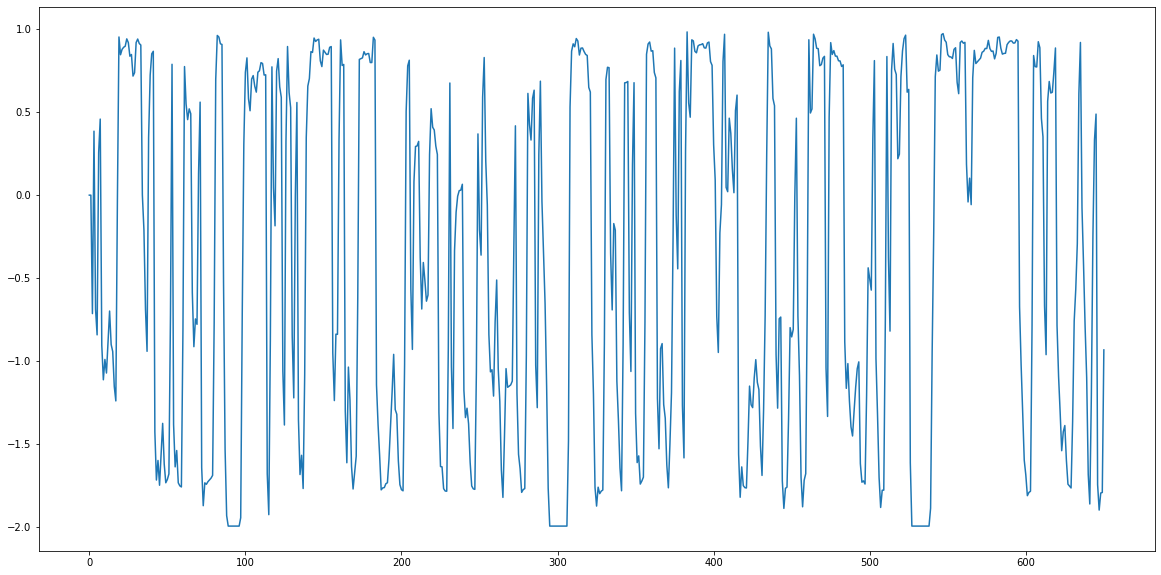

In [65]:
plt.figure(figsize=(20, 10))

plt.plot(samples[110,labels[0,:]>=0,2])


### Visualize the 1-stage model's output (unnormalized probs)

In [135]:
import matplotlib.pyplot as plt
import os
import numpy as np
import matplotlib


data_root_dir = "D:/eat_detection/results/"

def read_prob(prob_loc, gt_loc, video_idx):
    f_prob = open(os.path.join(prob_loc,f"features_{video_idx}.txt"),"r")
    f_gt = open(os.path.join(gt_loc,video_idx,"gt_frame_3labels.txt"),"r")
    # default sample value is 0, and default label is -1( will be ingored when computing loss)
    samples = np.ones((raw_seq_len,raw_sample_len,3)) * (-1)
    labels = np.ones((raw_seq_len,raw_sample_len)) * (-1)
    for col_idx, line in enumerate(f_prob.readlines()):
        seq_probs = line.split("\n")[0].split("\t")[1:]
        for row_idx in range(0,len(seq_probs),3):
            position_idx = row_idx // 3  # the frame index in the current sequence
            frame_idx = col_idx * raw_stride + position_idx  # the frame index in the current frame list
            samples[position_idx,frame_idx,0:3] = seq_probs[row_idx:row_idx+3]
    frame_gt = [LABEL_TABLE[line.split("\n")[0].split("\t")[1]] for line in f_gt.readlines()]
    for idx in range(0,raw_seq_len):
        labels[idx,idx:idx+len(frame_gt)-raw_seq_len+1] = frame_gt[idx:idx+len(frame_gt)-raw_seq_len+1]
    f_prob.close()
    f_gt.close()
    return samples.astype("float"),labels.astype("int")
    
def read_raw_samples(prob_loc,gt_loc,video_list):
    sample_list = []
    label_list = []
    for video_idx in video_list:
        cur_samples,cur_labels = read_prob(prob_loc, gt_loc, video_idx)
        sample_list.append(cur_samples)
        label_list.append(cur_labels)
    samples = np.concatenate(sample_list)
    labels = np.concatenate(label_list)
    return samples, labels

result_loc = "D:/eat_detection/results/"
gt_loc = "D:/OneDrive/PhD/work/eat_detection/CafeteriaData/all_labels/"
raw_stride = 1
raw_seq_len = 16
raw_sample_len = 10000
stratified_samples = [[] for i in range(raw_seq_len)]
for model_idx in range(1,4):
    prob_loc = f"{result_loc}{model_idx}/result_RES_LSTM_30_16_8_v4_test/frame_probs/"
    samples, labels = read_raw_samples(prob_loc,gt_loc)
    for position_idx in range(seq_len):
        stratified_samples[position_idx].append(samples[position_idx])
stratified_samples = np.array(stratified_samples)    

sample_max = np.max(stratified_samples,axis = 1)
sample_min = np.min(stratified_samples,axis = 1)

In [136]:
#result_loc = "/scratch1/zeyut/eat_detection/results/"
#gt_loc = "/scratch1/zeyut/eat_detection/all_labels/"
result_loc = data_root_dir + "results_10runs_RES_BILSTM/"
gt_loc = data_root_dir + "all_labels/"
LABEL_TABLE = {"bite": 0, "drink": 1, "non_intake": 2}
raw_stride = 1
raw_seq_len = 16
raw_sample_len = 20000
stratified_samples = [[] for i in range(raw_seq_len)]
stratified_labels = [[] for i in range(raw_seq_len)]

#video_list = [f[6:13] for f in os.listdir(prob_loc)]
#video_list = ["p020_c1"] #from train set
#video_list = ["p072_c1"] #from test set
### p110_c1: plot model volatility
### p192_c2: plot difference in 1-stage vs 2stage
video_list = ["p192_c2"] #from validation set
    
for model_idx in range(1,11):
    prob_loc = f"{result_loc}{model_idx}/result_val/frame_features/"
    samples, labels = read_raw_samples(prob_loc,gt_loc,video_list)
    for position_idx in range(raw_seq_len):
        stratified_samples[position_idx].append(samples[position_idx])
        stratified_labels[position_idx].append(labels[position_idx])
stratified_samples = np.array(stratified_samples)    
stratified_labels = np.array(stratified_labels)    

sample_max = np.max(stratified_samples,axis = 1)
sample_min = np.min(stratified_samples,axis = 1)

FileNotFoundError: [Errno 2] No such file or directory: 'D:/eat_detection/results/results_10runs_RES_BILSTM/1/result_val/frame_features/features_p192_c2.txt'

### Plot the prob range for different frame offsets

In [2]:
# use results from model 2
max_seq_offsets = np.max(stratified_samples[:,2,:,:],axis = 0)
min_seq_offsets = np.min(stratified_samples[:,2,:,:],axis = 0)
min_seq_offsets.shape

NameError: name 'stratified_samples' is not defined

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


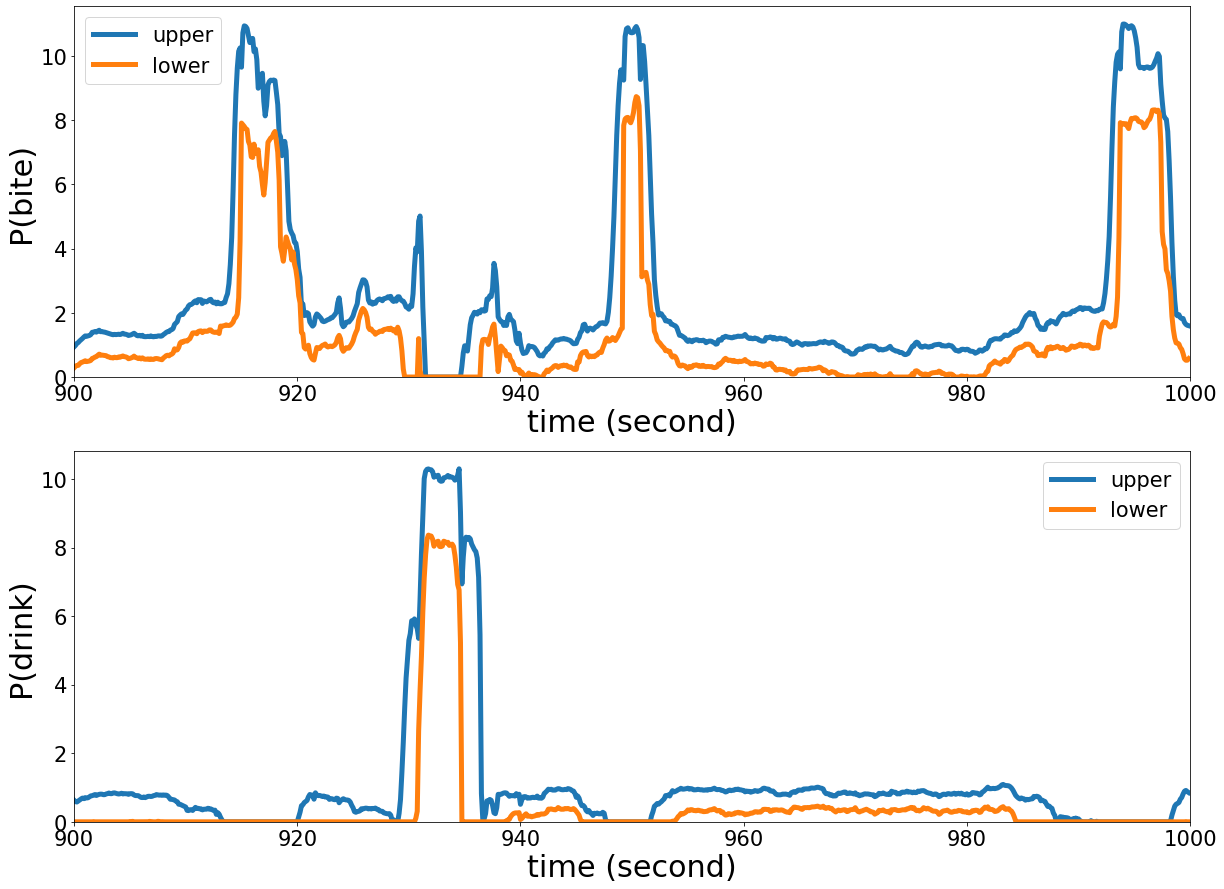

In [133]:

font = {'weight' : 'normal','size': 21}
matplotlib.rc('font', **font)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

plt.figure(figsize=(20, 15))
plt.subplot(2, 1, 1)

lim_range = [7200,8000]
time_axis = np.arange(lim_range[0],lim_range[1])/8

plt.plot(time_axis,max_seq_offsets[lim_range[0]:lim_range[1],0],linewidth=5.0)
plt.plot(time_axis,min_seq_offsets[lim_range[0]:lim_range[1],0],linewidth=5.0)
plt.xlim([lim_range[0]/8,lim_range[1]/8])

plt.ylim(bottom=0)
plt.xlabel("time (second)",fontsize='x-large',fontweight="normal")
plt.ylabel("P(bite)",fontsize='x-large',fontweight="normal")
plt.legend(["upper","lower"])

plt.subplot(2, 1, 2)

lim_range = [7200,8000]
time_axis = np.arange(lim_range[0],lim_range[1])/8
plt.plot(time_axis,max_seq_offsets[lim_range[0]:lim_range[1],1],linewidth=5.0)
plt.plot(time_axis,min_seq_offsets[lim_range[0]:lim_range[1],1],linewidth=5.0)
plt.xlim([lim_range[0]/8,lim_range[1]/8])
plt.ylim(bottom=0)
plt.xlabel("time (second)",fontsize='x-large',fontweight="normal")
plt.ylabel("P(drink)",fontsize='x-large',fontweight="normal")
plt.legend(["upper","lower"])
plt.savefig("./plotDifferentOffsets.eps")


### Plot the prob range for different models

In [114]:
# use results from model 0
max_seq_models = np.max(stratified_samples[7,:,:,:],axis = 0)
min_seq_models = np.min(stratified_samples[7,:,:,:],axis = 0)
min_seq_models.shape

(20000, 3)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


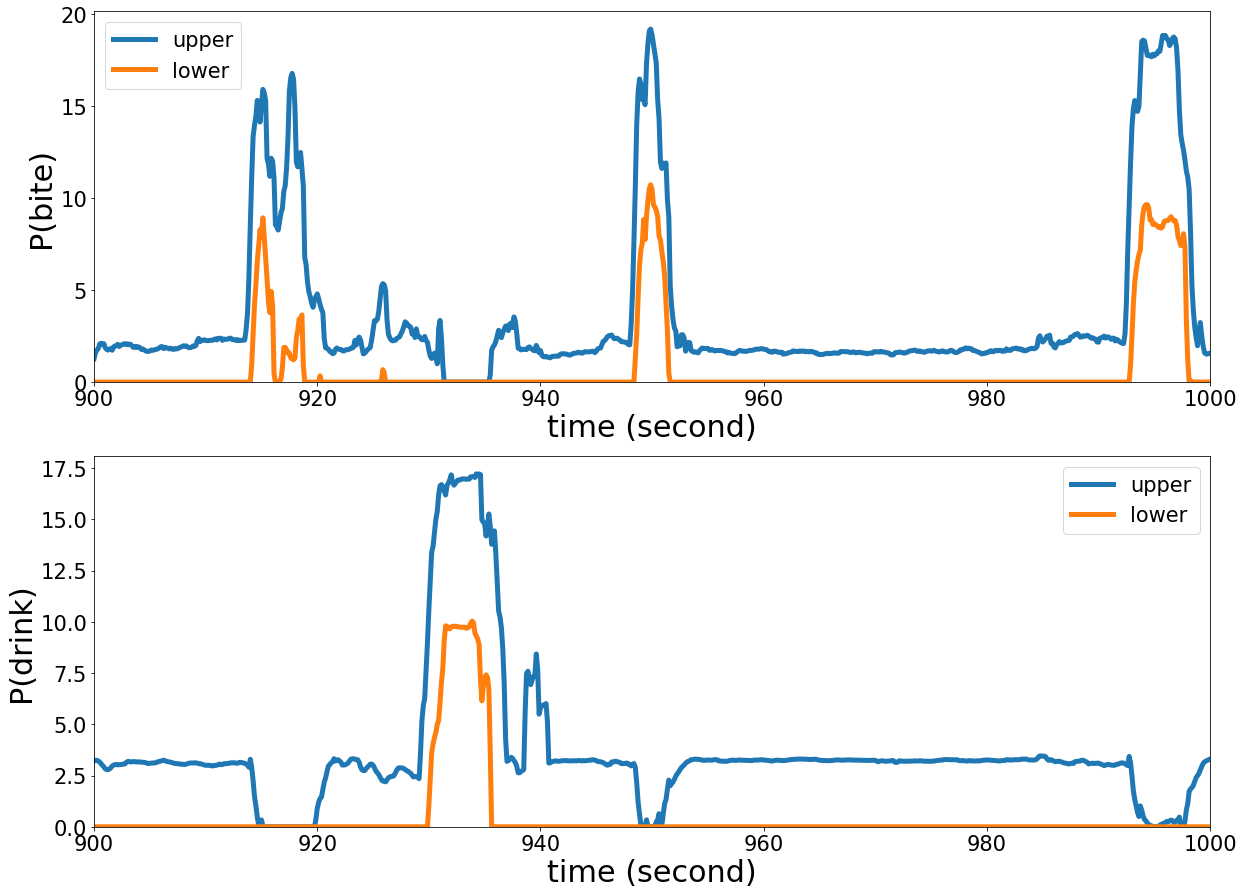

In [134]:
font = {'weight' : 'normal','size': 21}
matplotlib.rc('font', **font)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

plt.figure(figsize=(20, 15))
plt.subplot(2, 1, 1)

lim_range = [7200,8000]
time_axis = np.arange(lim_range[0],lim_range[1])/8

plt.plot(time_axis,max_seq_models[lim_range[0]:lim_range[1],0],linewidth=5.0)
plt.plot(time_axis,min_seq_models[lim_range[0]:lim_range[1],0],linewidth=5.0)
plt.xlim([lim_range[0]/8,lim_range[1]/8])

plt.ylim(bottom=0)
plt.xlabel("time (second)",fontsize='x-large',fontweight="normal")
plt.ylabel("P(bite)",fontsize='x-large',fontweight="normal")
plt.legend(["upper","lower"])

plt.subplot(2, 1, 2)

lim_range = [7200,8000]
time_axis = np.arange(lim_range[0],lim_range[1])/8
plt.plot(time_axis,max_seq_models[lim_range[0]:lim_range[1],1],linewidth=5.0)
plt.plot(time_axis,min_seq_models[lim_range[0]:lim_range[1],1],linewidth=5.0)
plt.xlim([lim_range[0]/8,lim_range[1]/8])
plt.ylim(bottom=0)
plt.xlabel("time (second)",fontsize='x-large',fontweight="normal")
plt.ylabel("P(drink)",fontsize='x-large',fontweight="normal")
plt.legend(["upper","lower"])
plt.savefig("./plotDifferentTraining.eps")

### Plot the prediction difference between 1-stage and 2-stage

In [139]:
LABEL_TABLE = {"bite": 0, "drink": 1, "non_intake": 2}

def read_gt(gt_loc,video_idx):
    f_gt = open(os.path.join(gt_loc,f"{video_idx}/gt_ges_3labels.txt"),"r")
    # default sample value is 0, and default label is -1( will be ingored when computing loss)
    gt = []
    for line in f_gt.readlines():
        label, start, end = line.split("\n")[0].split("\t")
        gt.append([LABEL_TABLE[label],int(start),int(end)])
    f_gt.close()
    return convertToFrameLabels(gt)

def read_preds(pred_loc,video_idx):
    f_pred = open(os.path.join(pred_loc,f"ges_{video_idx}.txt"),"r")
    # default sample value is 0, and default label is -1( will be ingored when computing loss)
    preds = []
    for line in f_pred.readlines():
        label, start, end = line.split("\n")[0].split("\t")
        preds.append([int(label),int(start),int(end)])
    f_pred.close()
    return convertToFrameLabels(preds)

def convertToFrameLabels(labels):
    
    framePreds = np.ones(labels[-1][-1]+1) * 2
    for ges in labels:
        framePreds[ges[1]:ges[2]+1] = ges[0]
    return framePreds

In [205]:
local_pred_loc = data_root_dir + "results_10runs_x3d-s/2/result_test/ges_boundaries/"
global_pred_loc = data_root_dir + "result_single_lstm_x3d-s_13_2stage_all/2/ges_boundaries/"
gt_loc = data_root_dir + f"VideoData_independent_{fps}hz/test_set/"
fps = 5


In [226]:
font = {'weight' : 'normal','size': 21}
matplotlib.rc('font', **font)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

matplotlib.rcParams['axes.spines.left'] = False
matplotlib.rcParams['axes.spines.right'] = False
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.bottom'] = True

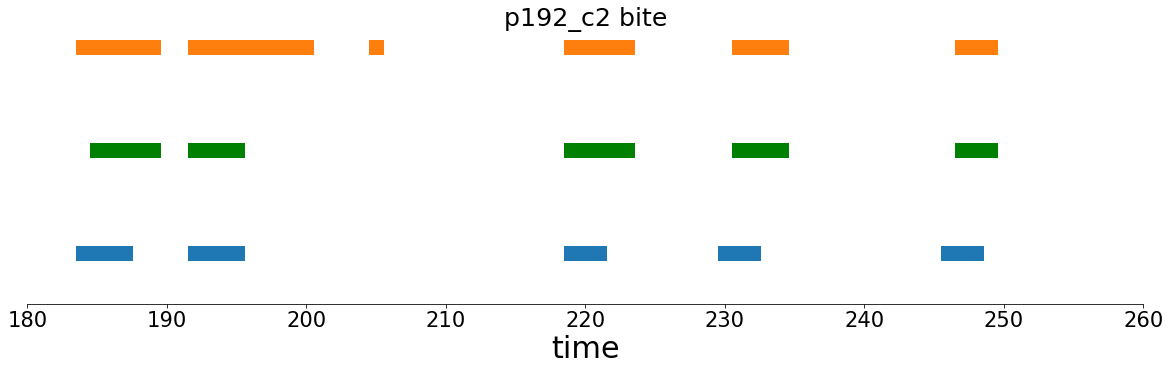

In [227]:
video_idx = "p192_c2"
local_preds = read_preds(local_pred_loc,video_idx)
global_preds = read_preds(global_pred_loc,video_idx)
gt = read_gt(gt_loc,video_idx)

disLabel = 0
plt.figure(figsize=(20, 5))
plt.title(f"{video_idx} bite")
plt.scatter(np.arange(len(local_preds))//fps,
            (local_preds==disLabel)*3,
            color="C1",
            s = 200,
            marker=",")
plt.scatter(np.arange(len(global_preds))//fps,
            (global_preds==disLabel)*2,
            color="g",
            s = 200,
            marker=",")
plt.scatter(np.arange(len(gt))//fps,
            (gt==disLabel)*1,
            color="C0",
            s = 200,
            marker=",")

plt.ylim(bottom=0.5)
plt.xlabel("time",fontsize='x-large')
plt.xlim([900//fps,1300//fps])
#plt.yticks([1,2,3], ["Local detector","Global detector","GT"])
#plt.axis("off")
ax = plt.gca()
ax.get_yaxis().set_visible(False)

plt.box("off")
#plt.ylabel("Predictions",fontsize='x-large')
#plt.legend(["Local detector","Global detector","GT"])

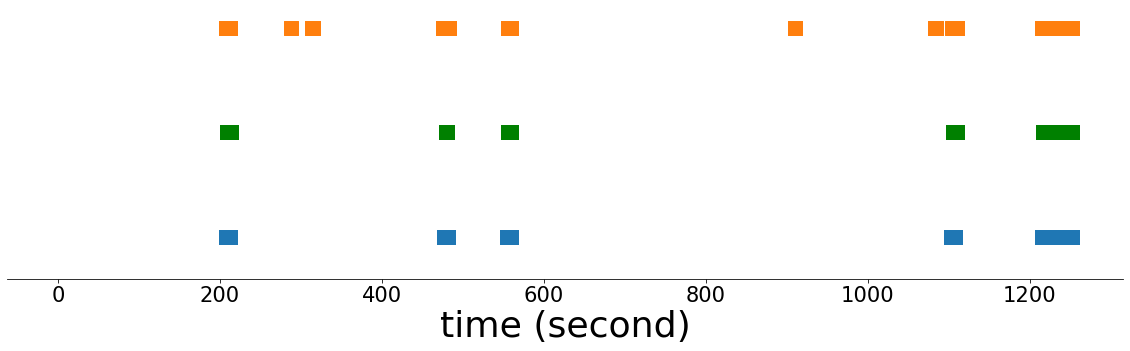

In [258]:
video_idx = "p259_c1"
local_preds = read_preds(local_pred_loc,video_idx)
global_preds = read_preds(global_pred_loc,video_idx)
gt = read_gt(gt_loc,video_idx)

disLabel = 1
plt.figure(figsize=(20, 5))
#plt.title(f"{video_idx} drink")
plt.scatter(np.arange(len(local_preds))//fps,
            (local_preds==disLabel)*2,
            color="C1",
            s = 200,
            marker=",")
plt.scatter(np.arange(len(global_preds))//fps,
            (global_preds==disLabel)*1.5,
            color="g",
            s = 200,
            marker=",")
plt.scatter(np.arange(len(gt))//fps,
            (gt==disLabel)*1,
            color="C0",
            s = 200,
            marker=",")

plt.ylim(bottom=0.8)
plt.xlabel("time (second)",fontsize='xx-large')
plt.yticks([1,1.5,2], ["Local detector","Global detector","Ground truth"],fontsize='x-large')
#plt.xlim([900,1300])
#plt.axis("off")
ax = plt.gca()
ax.get_yaxis().set_visible(False)
plt.savefig("./reduceFP.eps",bbox_inches='tight')


### Draw a symbolic picture for global patterns 

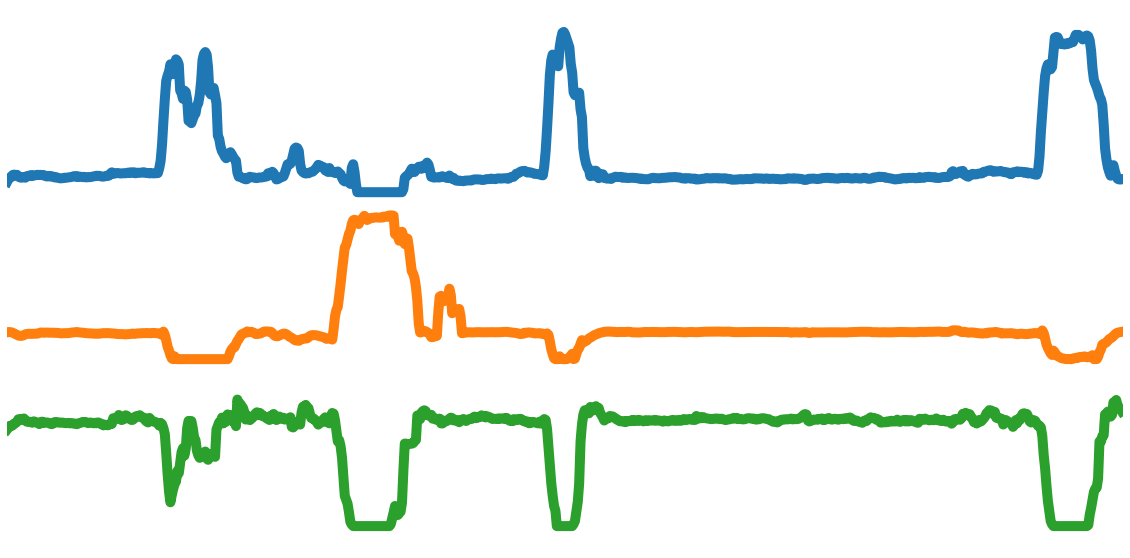

In [130]:
plt.figure(figsize=(20, 10))

lim_range = [7200,8000]
time_axis = np.arange(lim_range[0],lim_range[1])/8

plt.plot(time_axis,40+max_seq_models[lim_range[0]:lim_range[1],0],linewidth=10.0)
plt.plot(time_axis,20+max_seq_models[lim_range[0]:lim_range[1],1],linewidth=10.0)
plt.plot(time_axis,max_seq_models[lim_range[0]:lim_range[1],2],linewidth=10.0)
plt.xlim([lim_range[0]/8,lim_range[1]/8])
plt.axis('off')
plt.savefig("./patternPicture.png")

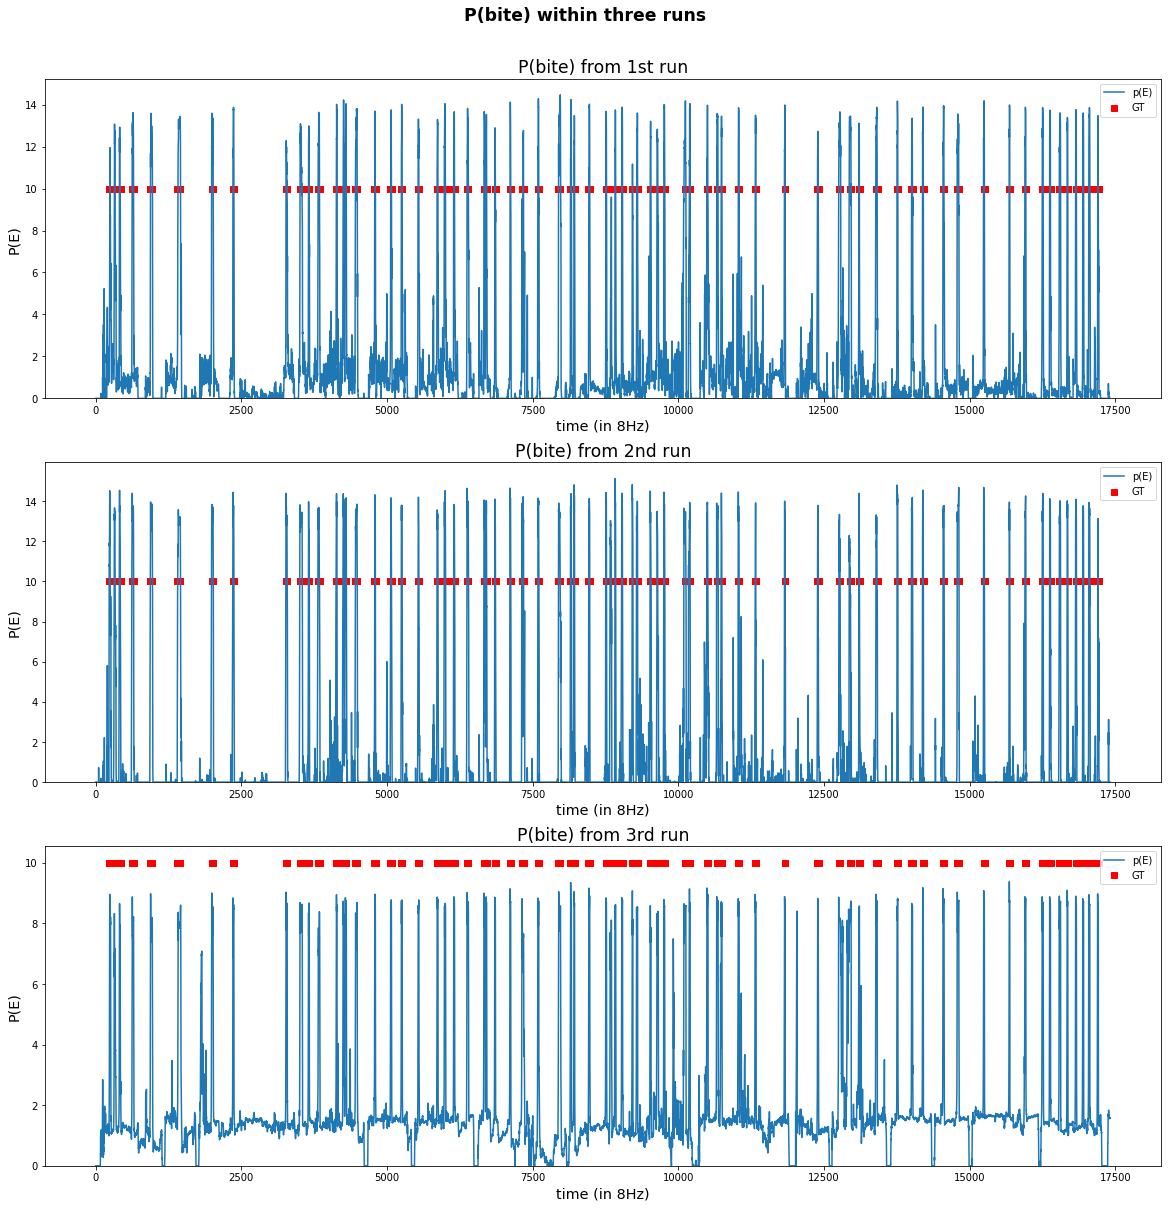

In [10]:
plt.figure(figsize=(20, 20))
plt.suptitle("P(bite) within three runs",fontsize='xx-large',fontweight='semibold',y=0.93)

plt.subplot(3, 1, 1)
plt.title("P(bite) from 1st run",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[0,0,stratified_samples[0,0,:,0]>=0,0])
plt.scatter(np.arange(len(stratified_labels[0,0,stratified_labels[0,0,:]>=0])),
            (stratified_labels[0,0,stratified_labels[0,0,:]>=0] == 0).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

plt.subplot(3, 1, 2)
plt.title("P(bite) from 2nd run",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[0,1,stratified_samples[0,1,:,0]>=0,0])
plt.scatter(np.arange(len(stratified_labels[0,1,stratified_labels[0,1,:]>=0])),
            (stratified_labels[0,1,stratified_labels[0,1,:]>=0] == 0).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

plt.subplot(3, 1, 3)
plt.title("P(bite) from 3rd run",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[0,2,stratified_samples[0,2,:,0]>=0,0])
plt.scatter(np.arange(len(stratified_labels[0,2,stratified_labels[0,2,:]>=0])),
            (stratified_labels[0,2,stratified_labels[0,2,:]>=0] == 0).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

#plt.show()
plt.savefig("./bite_1st_frame.jpg")

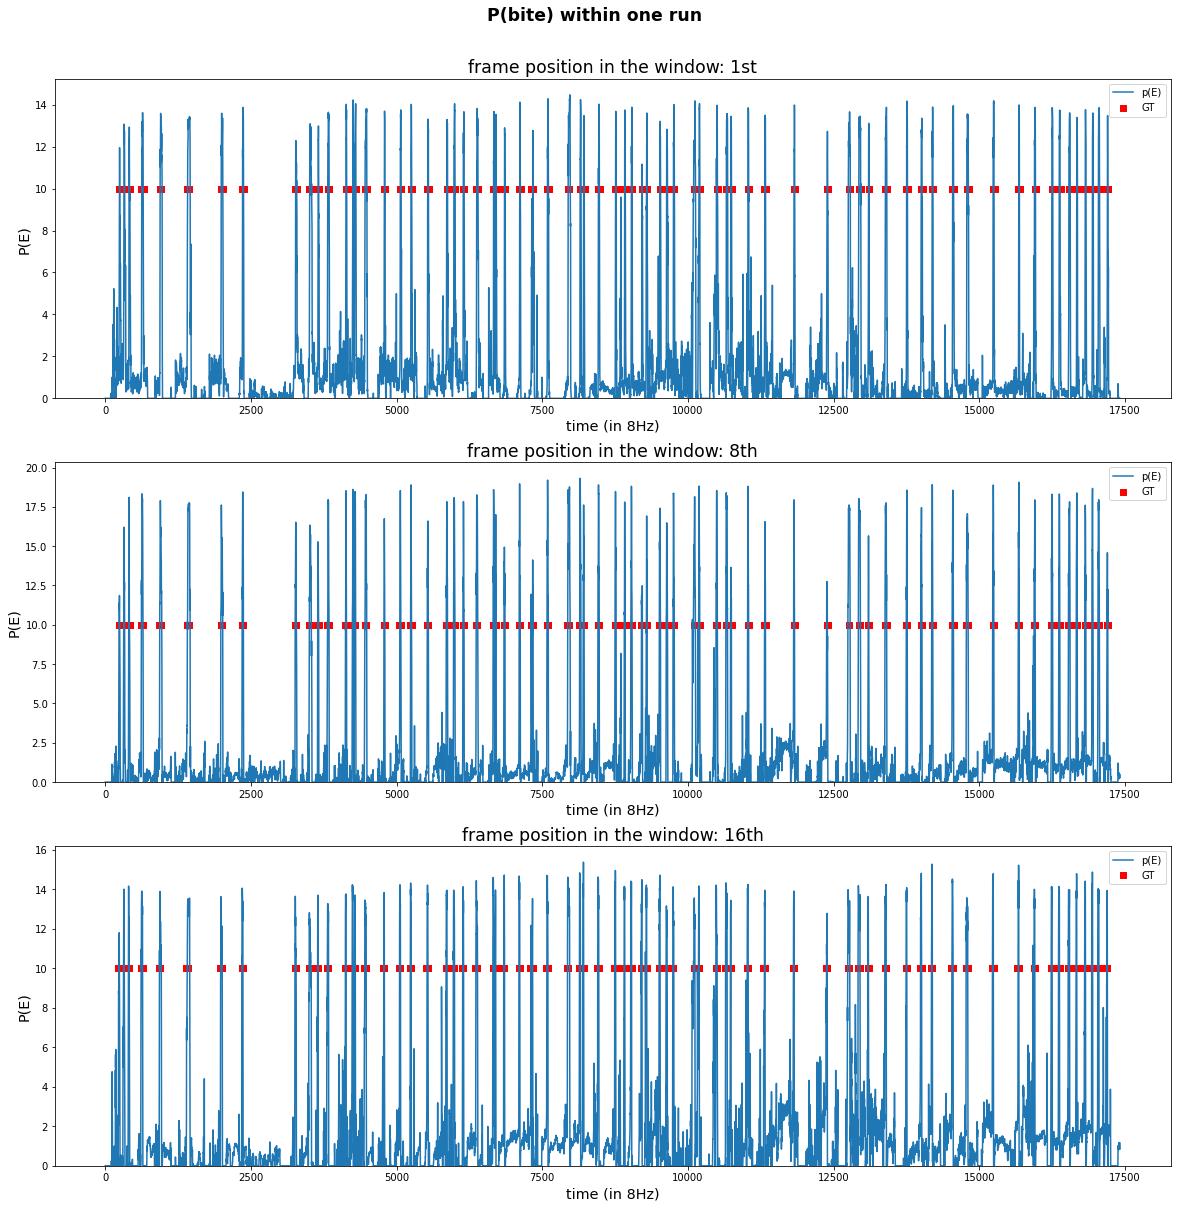

In [11]:
plt.figure(figsize=(20, 20))
plt.suptitle("P(bite) within one run",fontsize='xx-large',fontweight='semibold',y=0.93)

plt.subplot(3, 1, 1)
plt.title("frame position in the window: 1st",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[0,0,stratified_samples[0,0,:,0]>=0,0])
plt.scatter(np.arange(len(stratified_labels[0,0,stratified_labels[0,0,:]>=0])),
            (stratified_labels[0,0,stratified_labels[0,0,:]>=0] == 0).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

plt.subplot(3, 1, 2)
plt.title("frame position in the window: 8th",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[7,0,stratified_samples[7,0,:,0]>=0,0])
plt.scatter(np.arange(len(stratified_labels[7,0,stratified_labels[7,0,:]>=0])),
            (stratified_labels[7,0,stratified_labels[7,0,:]>=0] == 0).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

plt.subplot(3, 1, 3)
plt.title("frame position in the window: 16th",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[15,0,stratified_samples[15,0,:,0]>=0,0])
plt.scatter(np.arange(len(stratified_labels[15,0,stratified_labels[15,0,:]>=0])),
            (stratified_labels[15,0,stratified_labels[15,0,:]>=0] == 0).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

#plt.show()
plt.savefig("./bite_one_run.jpg")

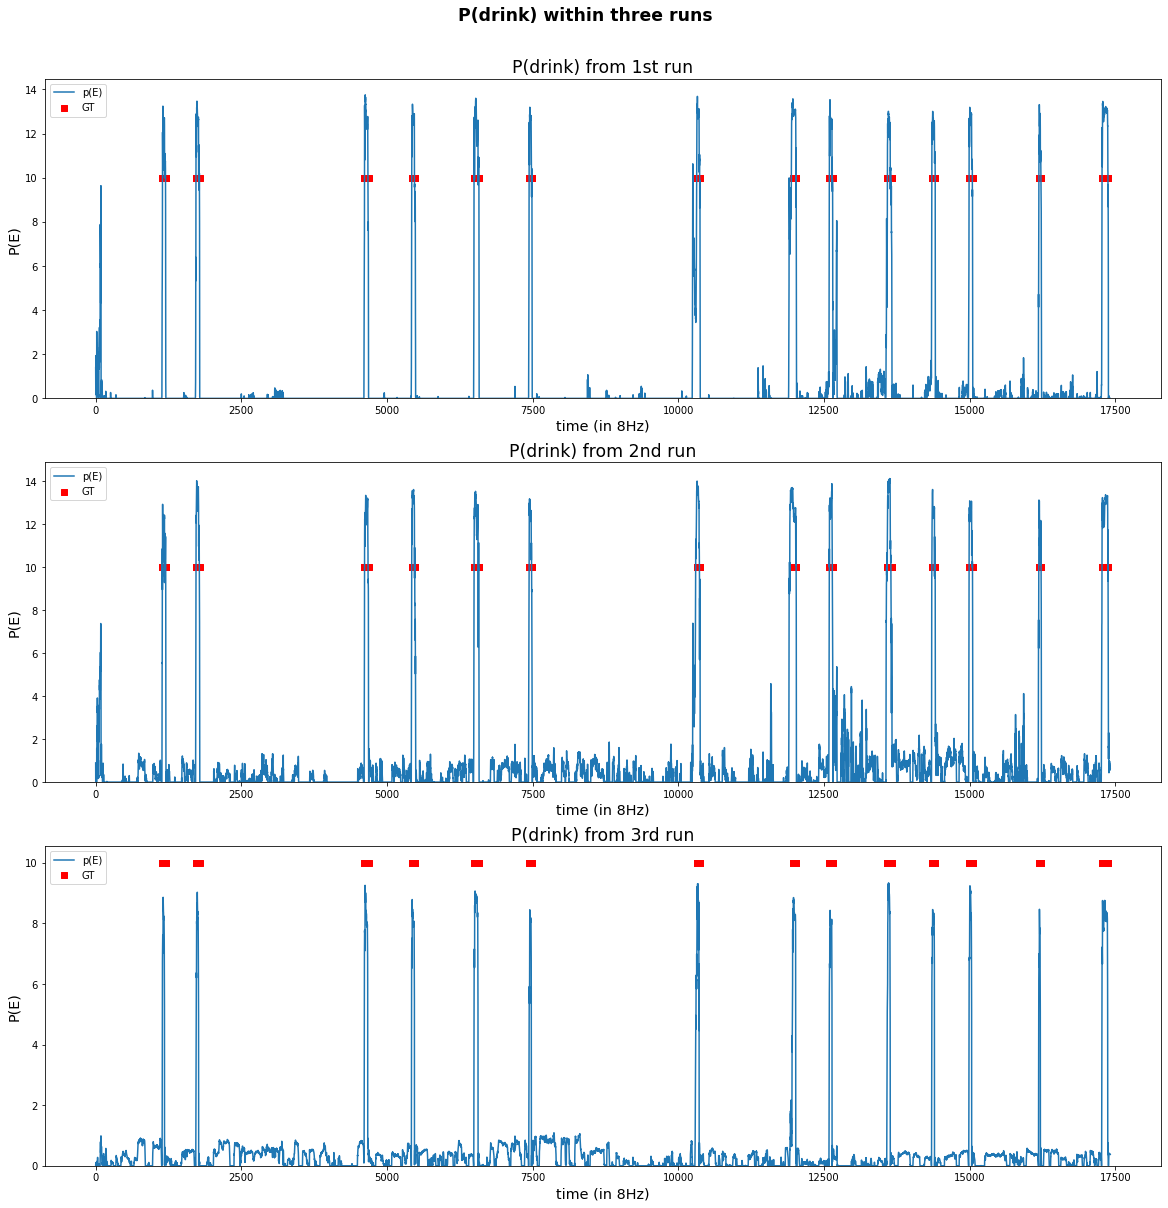

In [12]:
plt.figure(figsize=(20, 20))
plt.suptitle("P(drink) within three runs",fontsize='xx-large',fontweight='semibold',y=0.93)

plt.subplot(3, 1, 1)
plt.title("P(drink) from 1st run",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[0,0,stratified_samples[0,0,:,1]>=0,1])
plt.scatter(np.arange(len(stratified_labels[0,0,stratified_labels[0,0,:]>=0])),
            (stratified_labels[0,0,stratified_labels[0,0,:]>=0] == 1).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

plt.subplot(3, 1, 2)
plt.title("P(drink) from 2nd run",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[0,1,stratified_samples[0,1,:,1]>=0,1])
plt.scatter(np.arange(len(stratified_labels[0,1,stratified_labels[0,1,:]>=0])),
            (stratified_labels[0,1,stratified_labels[0,1,:]>=0] == 1).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

plt.subplot(3, 1, 3)
plt.title("P(drink) from 3rd run",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[0,2,stratified_samples[0,2,:,1]>=0,1])
plt.scatter(np.arange(len(stratified_labels[0,2,stratified_labels[0,2,:]>=0])),
            (stratified_labels[0,2,stratified_labels[0,2,:]>=0] == 1).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.legend(["p(E)","GT"])

#plt.show()
plt.savefig("./drink_1st_frame.jpg")

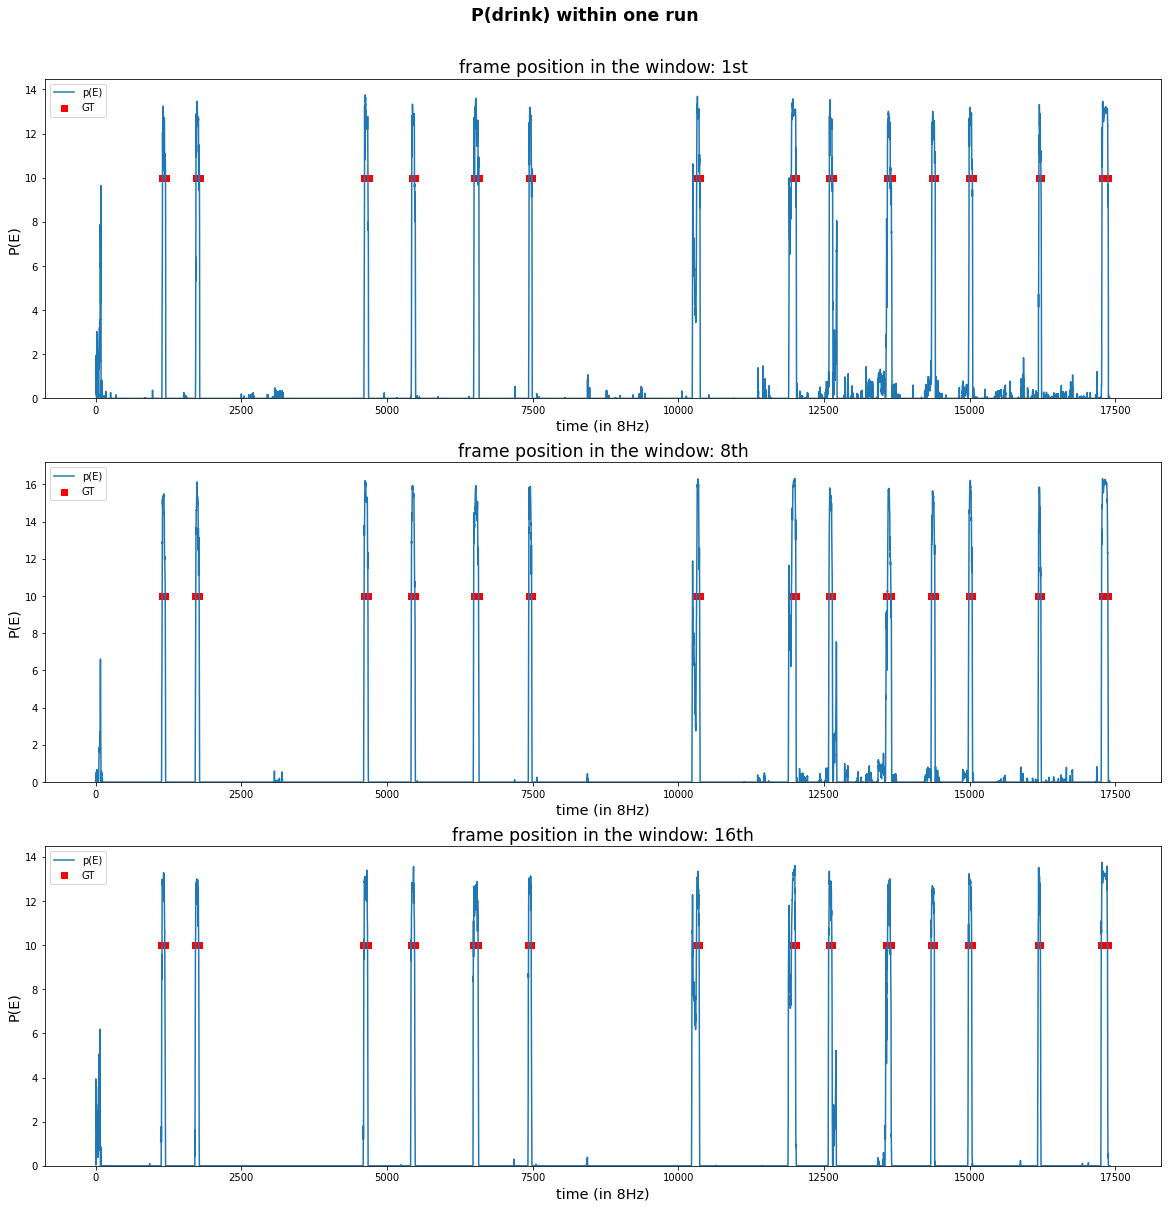

In [13]:
plt.figure(figsize=(20, 20))
plt.suptitle("P(drink) within one run",fontsize='xx-large',fontweight='semibold',y=0.93)

plt.subplot(3, 1, 1)
plt.title("frame position in the window: 1st",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[0,0,stratified_samples[0,0,:,1]>=0,1])
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.scatter(np.arange(len(stratified_labels[0,0,stratified_labels[0,0,:]>=0])),
            (stratified_labels[0,0,stratified_labels[0,0,:]>=0] == 1).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.legend(["p(E)","GT"])

plt.subplot(3, 1, 2)
plt.title("frame position in the window: 8th",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[7,0,stratified_samples[7,0,:,1]>=0,1])
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.scatter(np.arange(len(stratified_labels[7,0,stratified_labels[7,0,:]>=0])),
            (stratified_labels[7,0,stratified_labels[7,0,:]>=0] == 1).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.legend(["p(E)","GT"])

plt.subplot(3, 1, 3)
plt.title("frame position in the window: 16th",fontsize='xx-large',fontweight='medium')
plt.plot(stratified_samples[15,0,stratified_samples[15,0,:,1]>=0,1])
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.scatter(np.arange(len(stratified_labels[15,0,stratified_labels[15,0,:]>=0])),
            (stratified_labels[15,0,stratified_labels[15,0,:]>=0] == 1).astype("int")*11-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.legend(["p(E)","GT"])

#plt.show()
plt.savefig("./drink_one_run.jpg")

### Visualize the 2-stage model's output

In [82]:
import matplotlib.pyplot as plt

data_root_dir = "/scratch1/zeyut/eat_detection/"

def read_features(result_loc, gt_loc, video_idx):
    f_prob = open(os.path.join(result_loc,f"frame_features/features_{video_idx}.txt"),"r")
    f_gt = open(os.path.join(gt_loc,video_idx,"gt_frame_3labels.txt"),"r")
    # default sample value is -1, and default label is -1( will be ingored when computing loss)
    samples = np.ones((raw_seq_len,raw_sample_len,3)) *(-1)
    labels = np.ones((raw_seq_len,raw_sample_len)) * (-1)
    for col_idx, line in enumerate(f_prob.readlines()):
        seq_probs = line.split("\n")[0].split("\t")[1:]
        for row_idx in range(0,len(seq_probs),3):
            position_idx = row_idx // 3  # the frame index in the current sequence
            frame_idx = col_idx * raw_stride + position_idx  # the frame index in the current frame list
            samples[position_idx,frame_idx,0:3] = seq_probs[row_idx:row_idx+3]
    frame_gt = [LABEL_TABLE[line.split("\n")[0].split("\t")[1]] for line in f_gt.readlines()]
    for idx in range(0,raw_seq_len):
        labels[idx,idx:idx+len(frame_gt)-raw_seq_len+1] = frame_gt[idx:idx+len(frame_gt)-raw_seq_len+1]
    f_prob.close()
    f_gt.close()
    return samples.astype("float"),labels.astype("int")

def read_probs(result_loc, gt_loc, video_idx):
    f_prob = open(os.path.join(result_loc,f"frame_probs/probs_{video_idx}.txt"),"r")
    f_gt = open(os.path.join(gt_loc,video_idx,"gt_frame_3labels.txt"),"r")
    # default sample value is -1, and default label is -1( will be ingored when computing loss)
    samples = np.ones((raw_seq_len,raw_sample_len,3)) *(-1)
    labels = np.ones((raw_seq_len,raw_sample_len)) * (-1)
    for col_idx, line in enumerate(f_prob.readlines()):
        seq_probs = line.split("\n")[0].split("\t")[1:]
        for row_idx in range(0,len(seq_probs),3):
            position_idx = row_idx // 3  # the frame index in the current sequence
            frame_idx = col_idx * raw_stride + position_idx  # the frame index in the current frame list
            samples[position_idx,frame_idx,0:3] = seq_probs[row_idx:row_idx+3]
    frame_gt = [LABEL_TABLE[line.split("\n")[0].split("\t")[1]] for line in f_gt.readlines()]
    for idx in range(0,raw_seq_len):
        labels[idx,idx:idx+len(frame_gt)-raw_seq_len+1] = frame_gt[idx:idx+len(frame_gt)-raw_seq_len+1]
    f_prob.close()
    f_gt.close()
    return samples.astype("float"),labels.astype("int")

def read_raw_samples(result_loc,gt_loc,video_list):
    sample_list = []
    label_list = []
    for video_idx in video_list:
        cur_samples,cur_labels = read_probs(result_loc, gt_loc, video_idx)
        sample_list.append(cur_samples)
        label_list.append(cur_labels)
    samples = np.concatenate(sample_list)
    labels = np.concatenate(label_list)
    return samples, labels

def read_2nd_prob(result_loc,video_idx,sample_idx):
    f_prob = open(os.path.join(result_loc,f"frame_probs/probs_{video_idx}_{sample_idx}.txt"),"r")
    f_pred = open(os.path.join(result_loc,f"frame_preds/sub_preds_{video_idx}_{sample_idx}.txt"),"r")
    # default prob value is -1, and default label is -1( will be ingored when computing loss)
    probs = np.ones((sample_len,3)) *(-1)
    labels = np.ones(sample_len) * (-1)
    readin_probs = np.array([np.array(line.split("\n")[0].split("\t")[1:]).astype(float) for line in f_prob.readlines()])
    readin_labels = np.array([int(line.split("\n")[0].split("\t")[1]) for line in f_pred.readlines()])
    probs[sample_idx:sample_idx+len(readin_probs)] = readin_probs
    labels[sample_idx:sample_idx+len(readin_labels)] = readin_labels
    f_prob.close()
    f_pred.close()
    return probs.astype("float"),labels.astype("int")
    
def read_2nd_output(result_loc,video_list):
    output_list = []
    label_list = []
    for video_idx in video_list:
        output_group = []
        label_group = []
        for sample_idx in range(3):
            cur_output,cur_labels = read_2nd_prob(result_loc,video_idx,sample_idx)
            output_group.append(cur_output)
            label_group.append(cur_labels)
        output_list.append(output_group)
        label_list.append(label_group)
    output = np.concatenate(output_list)
    labels = np.concatenate(label_list)
    return output, labels

In [88]:
model_idx = 2
video_list = ["p096_c1"]

LABEL_TABLE = {"bite": 0, "drink": 1, "non_intake": 2}
raw_stride = 1
raw_seq_len = 16
raw_sample_len = 20000
sample_len = 5000

frame_idx = 4
feature_loc = data_root_dir+f"results_10runs_2unidirectional_ltsm/{model_idx}/result_test/"
first_probs,first_labels = read_raw_samples(feature_loc,
                                            data_root_dir+"all_labels/",
                                            video_list)
final_probs, final_labels = read_2nd_output(data_root_dir+f"/result_single_lstm_RES_LSTM_16_2stage_all/{model_idx}/",
                                          video_list)

real_len = np.sum(first_labels[0,:]>=0)



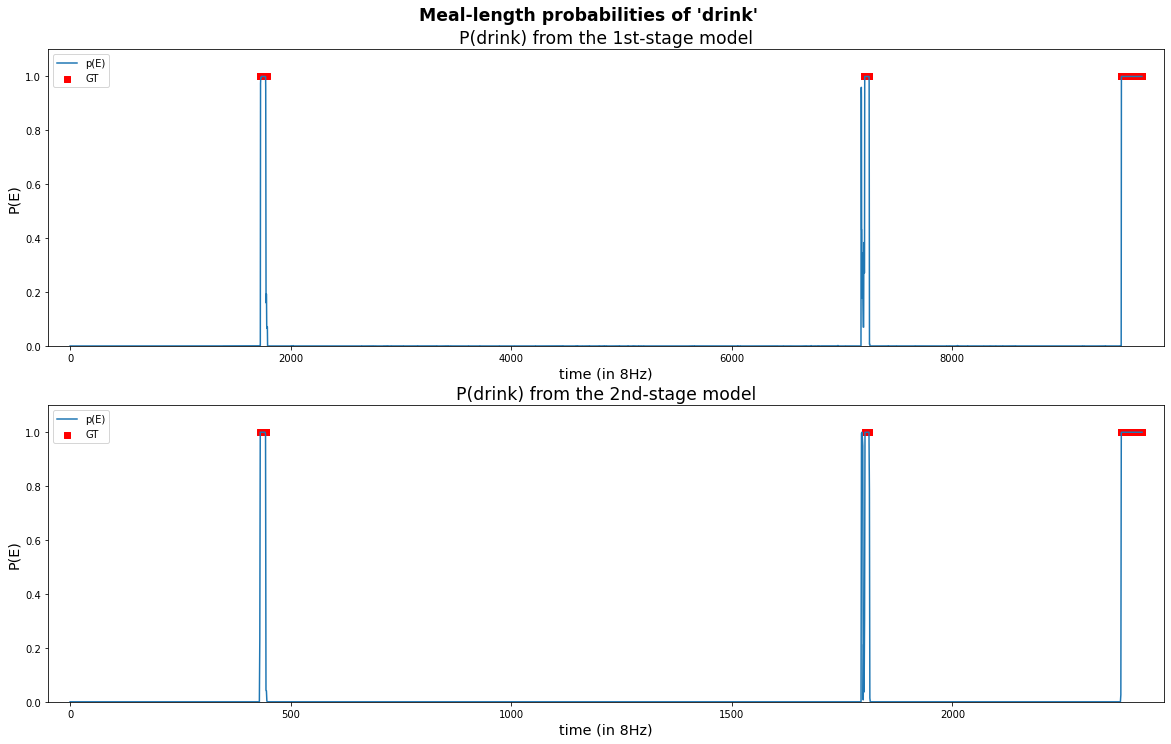

In [89]:
plt.figure(figsize=(20, 12))
plt.suptitle("Meal-length probabilities of 'drink'",fontsize='xx-large',fontweight='semibold',y=0.93)

plt.subplot(2, 1, 1)
plt.title("P(drink) from the 1st-stage model",fontsize='xx-large',fontweight='medium')
plt.plot(first_probs[frame_idx,first_probs[frame_idx,:,1]>=0,1])
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.scatter(np.arange(len(first_labels[frame_idx,first_labels[frame_idx,:]>=0])),
            (first_labels[frame_idx,first_labels[frame_idx,:]>=0] == 1).astype("int")*2-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlim([-200, real_len+200])
plt.legend(["p(E)","GT"])

plt.subplot(2, 1, 2)
plt.title("P(drink) from the 2nd-stage model",fontsize='xx-large',fontweight='medium')
plt.plot(final_probs[frame_idx//4,final_probs[frame_idx//4,:,1]>=0,1])
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.scatter(np.arange(len(final_labels[frame_idx//4,final_labels[frame_idx//4,:]>=0])),
            (final_labels[frame_idx//4,final_labels[frame_idx//4,:]>=0] == 1).astype("int")*2-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlim([-50, (real_len+200)//4])
plt.legend(["p(E)","GT"])

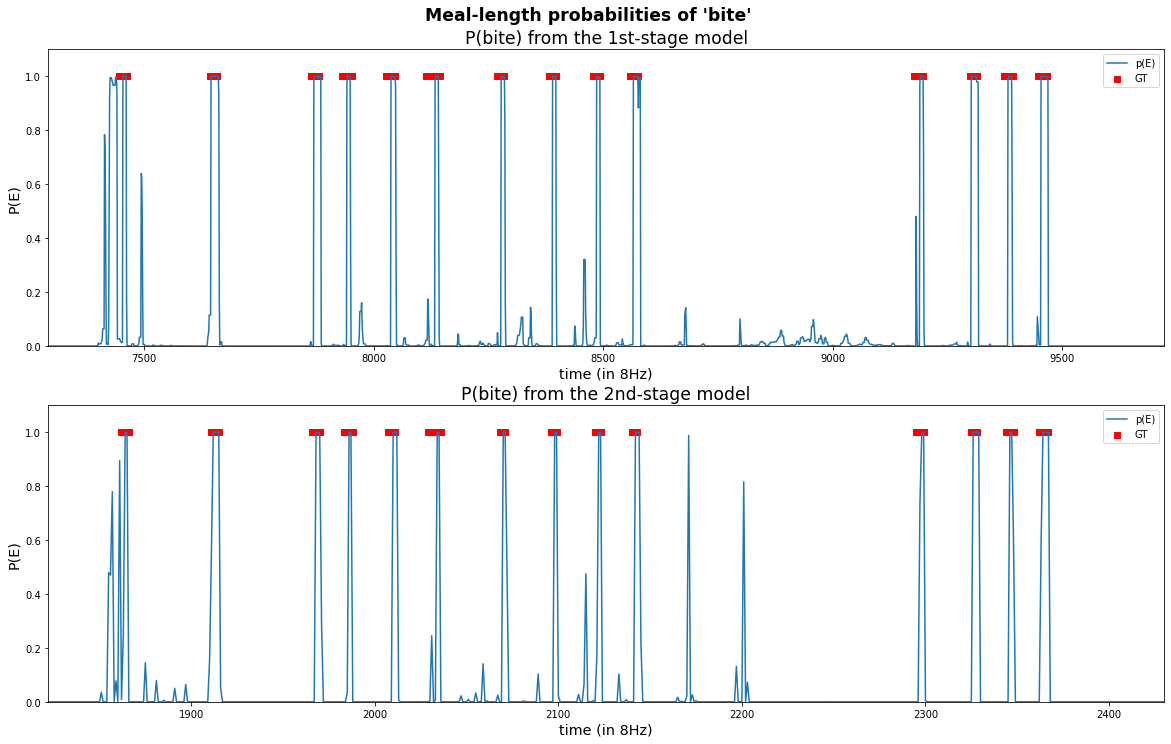

In [90]:
#lim_range = [-200, real_len//4]
lim_range = [real_len*3//4, real_len]

plt.figure(figsize=(20, 12))
plt.suptitle("Meal-length probabilities of 'bite'",fontsize='xx-large',fontweight='semibold',y=0.93)

plt.subplot(2, 1, 1)
plt.title("P(bite) from the 1st-stage model",fontsize='xx-large',fontweight='medium')
plt.plot(first_probs[frame_idx,first_probs[frame_idx,:,0]>=0,0])
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.scatter(np.arange(len(first_labels[frame_idx,first_labels[frame_idx,:]>=0])),
            (first_labels[frame_idx,first_labels[frame_idx,:]>=0] == 0).astype("int")*2-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlim(lim_range)
plt.legend(["p(E)","GT"])

plt.subplot(2, 1, 2)
plt.title("P(bite) from the 2nd-stage model",fontsize='xx-large',fontweight='medium')
plt.plot(final_probs[frame_idx//4,final_probs[frame_idx//4,:,0]>=0,0])
plt.xlabel("time (in 8Hz)",fontsize='x-large')
plt.ylabel("P(E)",fontsize='x-large')
plt.scatter(np.arange(len(final_labels[frame_idx//4,final_labels[frame_idx//4,:]>=0])),
            (final_labels[frame_idx//4,final_labels[frame_idx//4,:]>=0] == 0).astype("int")*2-1,
            color="r",
            marker=",")
plt.ylim(bottom=0)
plt.xlim([lim_range[0]//4,lim_range[1]//4])
plt.legend(["p(E)","GT"])
